In [ ]:
from option import Option, OptionParams
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def make_plot(data):
    
    X, Y, z = data
    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(projection="3d")

    surf = ax.plot_surface(
        X, Y, z,
        cmap="plasma",
        antialiased=True
    )
    ax.plot_wireframe(
        X, Y, z,
        rstride=10,
        cstride=10,
        color="black",
        alpha=0.35
    )
    ax.set_box_aspect((2.5, 2.5, 1))
    ax.set_xlabel("Time to maturity", labelpad=10)
    ax.set_ylabel("Underlying price", labelpad=10)
    ax.set_zlabel("Price of the option", labelpad=10)

    fig.colorbar(surf, shrink=0.6, aspect=15, pad = 0.12)
    plt.tight_layout()

    plt.show()

In [21]:
parameters = OptionParams(
    under = 690.62,
    strike = 691,
    divident = 0.0105,
    maturity = 1,
    rate  = 0.0345,
    volatility = 0.1462,
    call = False,
    name = "SP500"
)
option1 = Option(parameters)

In [22]:
option1.name

'SP500'

In [23]:
option1.get_info()


                                 SP500                          
        | Metric                    |                     Value |
        ---------------------------------------------------------
        | Price                     |                    €31.95 |
        | Strike                    |                   €691.00 |
        | Time to maturity          |                      1.00 |
        | Delta                     |                 -0.403430 |
        | Gamma                     |                  0.003805 |
        | Vega                      |                265.307884 |
        | Theta                     |                -11.605015 |
        | Rho                       |               -310.564235 |
        | Call or put               |                       Put |
        


In [24]:
paths = option1.brown_simul()
print(paths.shape)

(252, 250)


172


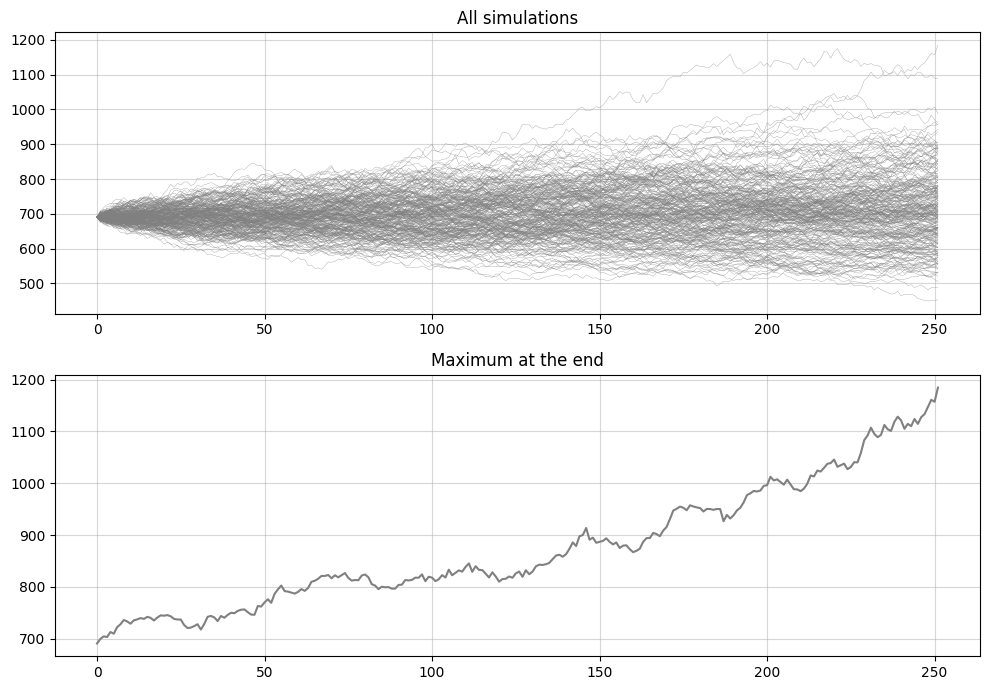

In [ ]:

maximum = max(paths[-1, :])
for i in range(250):
    if paths[-1, i] == maximum:
        print(i)
        idx = i
plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.plot(paths, linewidth = 0.2, c = 'grey')
plt.title("All simulations")
plt.grid(alpha = 0.5)
plt.subplot(2, 1, 2)
plt.plot(paths[:, idx], c = 'grey')
plt.title("Maximum at the end")
plt.grid(alpha = 0.5)
plt.tight_layout()
plt.show()

In [26]:
num = option1.price_evolv(mat=0.0001)
print(num)

0.6195638606025682


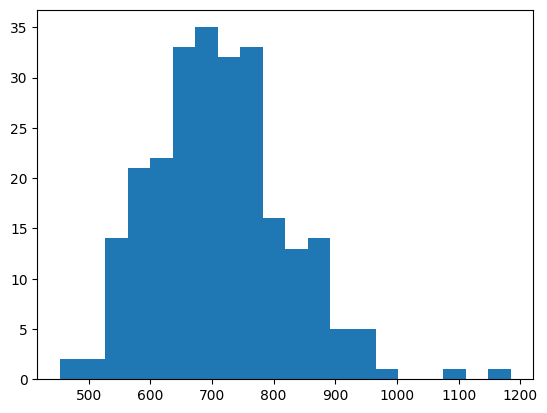

In [27]:
last = paths[-1, :]
plt.hist(last, bins=20)
plt.show()

In [ ]:
x = np.asarray(last) - parameters.strike
kde = gaussian_kde(x)

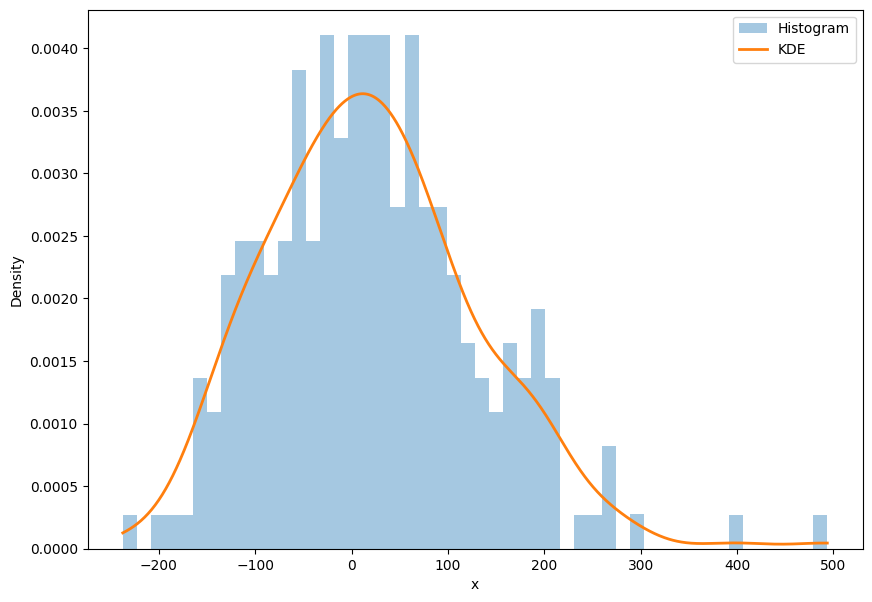

In [29]:
x_grid = np.linspace(x.min(), x.max(), 1000)
pdf = kde(x_grid)

plt.figure(figsize=(10, 7))
plt.hist(x, bins=50, density=True, alpha=0.4, label="Histogram")
plt.plot(x_grid, pdf, lw=2, label="KDE")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [30]:
from scipy.integrate import cumulative_trapezoid

cdf = cumulative_trapezoid(pdf, x_grid, initial=0)


In [31]:
cdf /= cdf[-1]


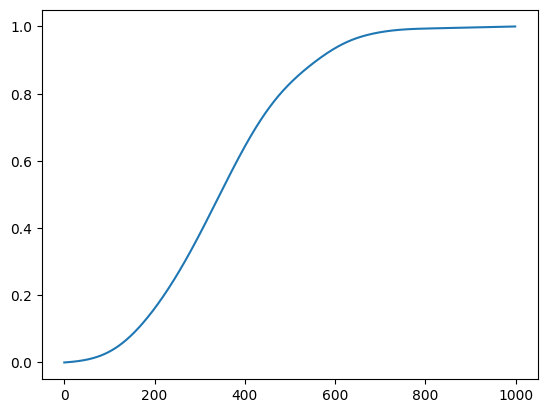

In [32]:
plt.plot(cdf)

In [33]:
def kde_quantile(q, x_grid, cdf):
    return np.interp(q, cdf, x_grid)
q10 = kde_quantile(0.10, x_grid, cdf)
q50 = kde_quantile(0.50, x_grid, cdf)
q90 = kde_quantile(0.90, x_grid, cdf)

print(q10, q50, q90)


-118.53208418423198 14.763840221795684 172.73666754338234


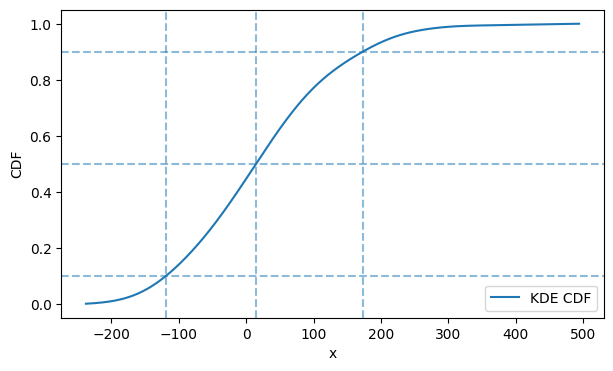

In [34]:
plt.figure(figsize=(7, 4))
plt.plot(x_grid, cdf, label="KDE CDF")

for q in [0.1, 0.5, 0.9]:
    plt.axhline(q, ls="--", alpha=0.5)
    plt.axvline(kde_quantile(q, x_grid, cdf), ls="--", alpha=0.5)

plt.xlabel("x")
plt.ylabel("CDF")
plt.legend()
plt.show()


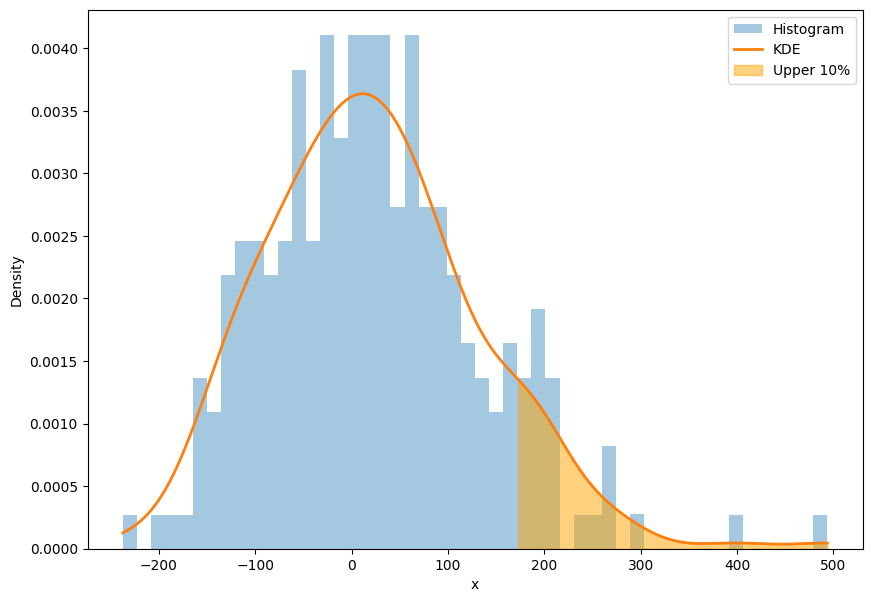

In [35]:
x_grid = np.linspace(x.min(), x.max(), 1000)
pdf = kde(x_grid)

plt.figure(figsize=(10, 7))
plt.hist(x, bins=50, density=True, alpha=0.4, label="Histogram")
plt.plot(x_grid, pdf, lw=2, label="KDE")
plt.fill_between(x_grid[x_grid > q90], pdf[x_grid >q90], color='orange', alpha=0.5, label="Upper 10%")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [36]:
prices = option1.price_simul()

252


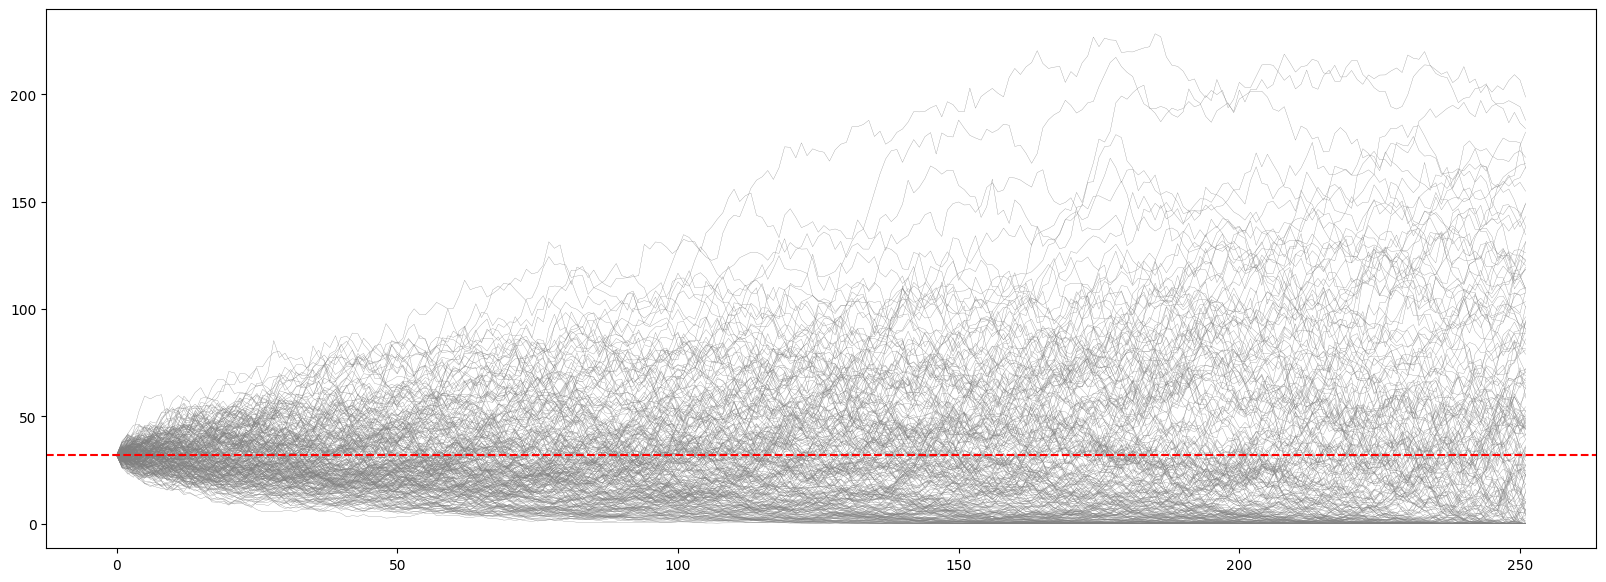

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 7))
plt.plot(prices, linewidth = 0.2, c = 'grey')
plt.axhline(option1.price(), linestyle = "--", c = 'red')
plt.show()

(250,)
0.0
(250,)
2.665300221135687


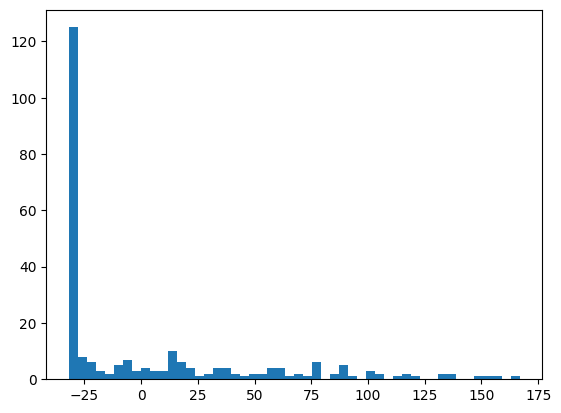

In [38]:
payoff = prices[-1, :]
print(payoff.shape)
print(min(payoff))
profit = payoff - option1.price()
print(profit.shape)
print(profit.mean())
plt.hist(profit, bins = 50)
plt.show()